# **Pengelompokan dan Klasifikasi Kondisi Motor Listrik Berdasarkan Data Sensor Menggunakan K-Means, Decision Tree serta Random Forest**

`M Wahyu Ayesha | Galang Rambu Anarki`

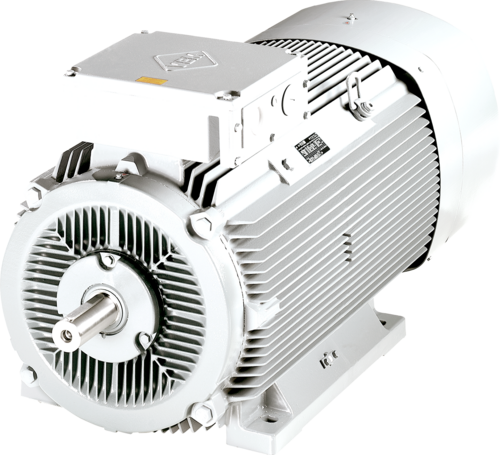

*Source: VEM motors GmbH, via Wikimedia Commons (CC BY-SA 4.0)*

# Daftar Isi

1. [Business Understanding](#a-business-understanding)
2. [Data Understanding](#b-data-understanding)
3. [Exploratory Data Analysis](#c-exploratory-data-analysis)
4. [Data Preprocesing](#d-data-preprocessing)
5. [Pemodelan Bagian 1 : K-Means Clustering](#e-pemodelan-bagian-1--k-means-clustering)
6. [Pemodelan Bagian 2 : Decision Tree](#f-pemodelan-bagian-2--decision-tree)
7. [Evaluasi](#g-evaluasi)
8. [Graphical User Interface](#h-graphical-user-interface-gui)

--------------

#  A. Business Understanding 

 ***A.1 Latar Belakang:***


> Motor listrik digunakan secara luas dalam industri listrik. Dataset yang digunakan pada proyek ini berisi data sensor dari Permanent Magnet Synchronous Motor (PMSM) yang diambil dari beberapa sesi pengukuran. Kondisi operasional motor dapat diamati melalui beberapa parameter, seperti arus, tegangan, suhu, kecepatan, dan torsi. Data sensor ini dapat dimanfaatkan untuk menemukan pola melalui proses clustering serta klasifikasi guna mengefisiensi dan memudahkann proses pemantauan kondisi motor.

 ***A.2 Tujuan*:**

> - mengelompokkan data motor listrik berdasarkan kemiripan karakteristik menggunakan algoritma K-Means
> - membentuk label cluster dari hasil clustering
> - membangun model AI Decision Tree dan Random Forest yang mampu memprediksi cluster/label dari suatu data pengukuran motor baru secara akurat.
> - membandingkan performa model algoritma Decision Tree dengan metode ensemble bagging (Random Forest)

-----

# B. Data Understanding

B.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

B.2 Import dataset

In [3]:
df = pd.read_csv('measures_v2.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


***Insight:***
>Dataset terdiri dari beberapa jenis sensor yang menggambarkan kondisi operasi motor listrik, yaitu:

>Variabel listrik: u_q, u_d, i_d, dan i_q yang merepresentasikan tegangan dan arus pada motor.

>Variabel mekanik: motor_speed dan torque yang menggambarkan kecepatan dan beban kerja motor.

>Variabel temperatur: pm, stator_winding, stator_tooth, stator_yoke, coolant, dan ambient yang menunjukkan suhu pada berbagai komponen motor serta lingkungan sekitar.

>Variabel identitas: profile_id yang menunjukkan identitas sesi atau profil eksperimen saat data dikumpulkan.

B.3 Menampilkan Informasi Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330816 entries, 0 to 1330815
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1330816 non-null  float64
 1   coolant         1330816 non-null  float64
 2   stator_winding  1330816 non-null  float64
 3   u_d             1330816 non-null  float64
 4   stator_tooth    1330816 non-null  float64
 5   motor_speed     1330816 non-null  float64
 6   i_d             1330816 non-null  float64
 7   i_q             1330816 non-null  float64
 8   pm              1330816 non-null  float64
 9   stator_yoke     1330816 non-null  float64
 10  ambient         1330816 non-null  float64
 11  torque          1330816 non-null  float64
 12  profile_id      1330816 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 132.0 MB


***Insight:***


>Dataset memiliki 1.330.816 baris dan 13 kolom yang berisi data sensor motor listrik.

>Seluruh kolom tidak memiliki missing value.

>Hampir semua kolom bertipe float (numerik) sehingga dapat langsung digunakan untuk analisis dan pemodelan.

B.4 Menampilkan Statistik deskriptif data

In [5]:
pd.options.display.float_format = '{:.2f}'.format

In [6]:
df.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00,1330816.00
mean,54.28,36.23,66.34,-25.13,56.88,2202.08,-68.72,37.41,58.51,48.19,24.57,31.11,40.79
std,44.17,21.79,28.67,63.09,22.95,1859.66,64.93,92.18,19.00,19.99,1.93,77.14,25.05
min,-25.29,10.62,18.59,-131.53,18.13,-275.55,-278.00,-293.43,20.86,18.08,8.78,-246.47,2.00
25%,12.07,18.70,42.79,-78.69,38.42,317.11,-115.41,1.10,43.15,31.99,23.18,-0.14,17.00
50%,48.94,26.90,65.11,-7.43,56.04,1999.98,-51.09,15.77,60.27,45.63,24.80,10.86,43.00
75%,90.03,49.86,88.14,1.47,75.59,3760.64,-2.98,100.61,72.01,61.46,26.22,91.60,65.00
max,133.04,101.60,141.36,131.47,111.95,6000.02,0.05,301.71,113.61,101.15,30.71,261.01,81.00


***Insight**:*

>Nilai setiap variabel memiliki rentang yang cukup besar, misalnya motor_speed berkisar dari sekitar -275 hingga 6000, dan torque dari -246 hingga 261.

>Variabel temperatur seperti pm, stator_winding, stator_tooth, dan stator_yoke memiliki rata-rata sekitar 48–66°C.

>Suhu lingkungan (ambient) memiliki variasi kecil dibanding variabel lain.

B.5 Menampilkan Jumlah Duplikasi data

In [7]:
df.duplicated().sum()

np.int64(0)

-------

# C. Exploratory Data Analysis

C.1 Menampilkan Histogram Untuk Melihat Distribusi Data

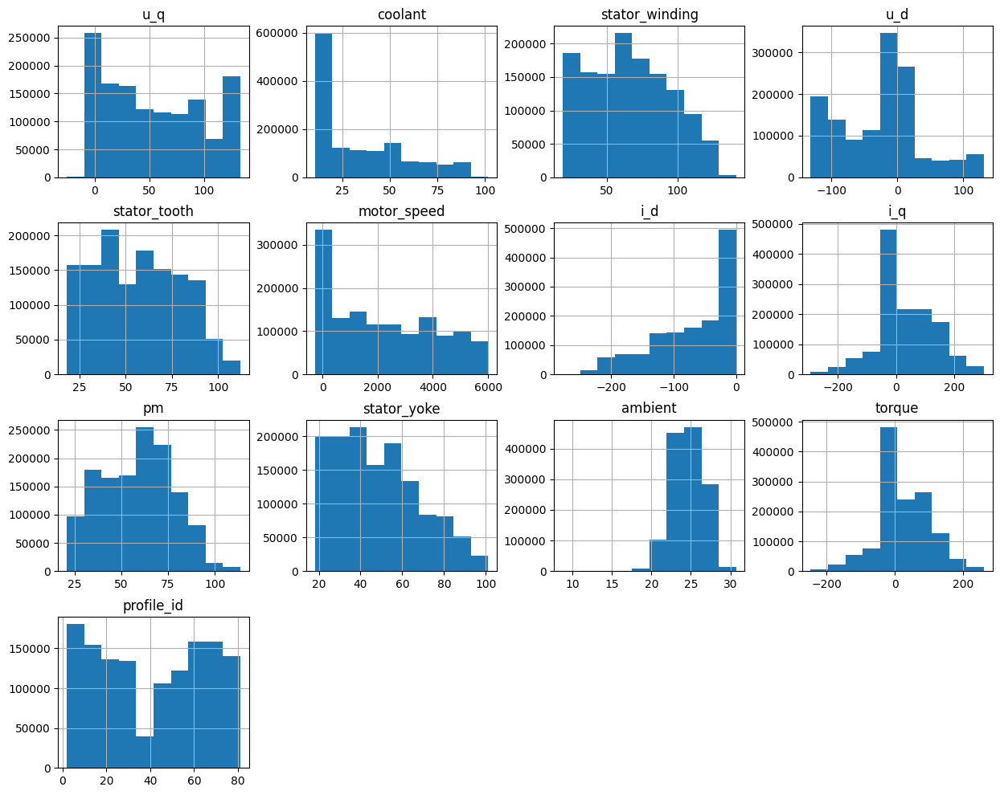

In [8]:
df.hist(figsize=(15,12))
plt.show()

***Insight:***

>Beberapa variabel seperti pm, stator_winding, stator_tooth, dan stator_yoke memiliki distribusi yang cukup menyerupai distribusi normal, dengan nilai yang banyak terkumpul di sekitar tengah rentangnya.

>Variabel motor_speed memiliki rentang nilai yang sangat lebar, mulai dari sekitar -275 hingga 6000, yang menunjukkan variasi kondisi operasi motor yang cukup besar.

>Variabel ambient memiliki distribusi yang lebih sempit dibandingkan fitur lain, dengan sebagian besar nilai berada di sekitar 20–30, sehingga menunjukkan bahwa suhu lingkungan relatif stabil.

>Beberapa variabel seperti torque dan i_q memiliki distribusi yang lebih menyebar dengan nilai negatif dan positif.

***Tindakan:***

>Karena beberapa fitur memiliki rentang nilai yang sangat berbeda, maka tindakan pada tahap selanjutnya akan dilakukan normalisasi atau standardisasi data sebelum proses pemodelan.

C.2 Menampilkan Boxplot Untuk Melihat Sebaran Outlier

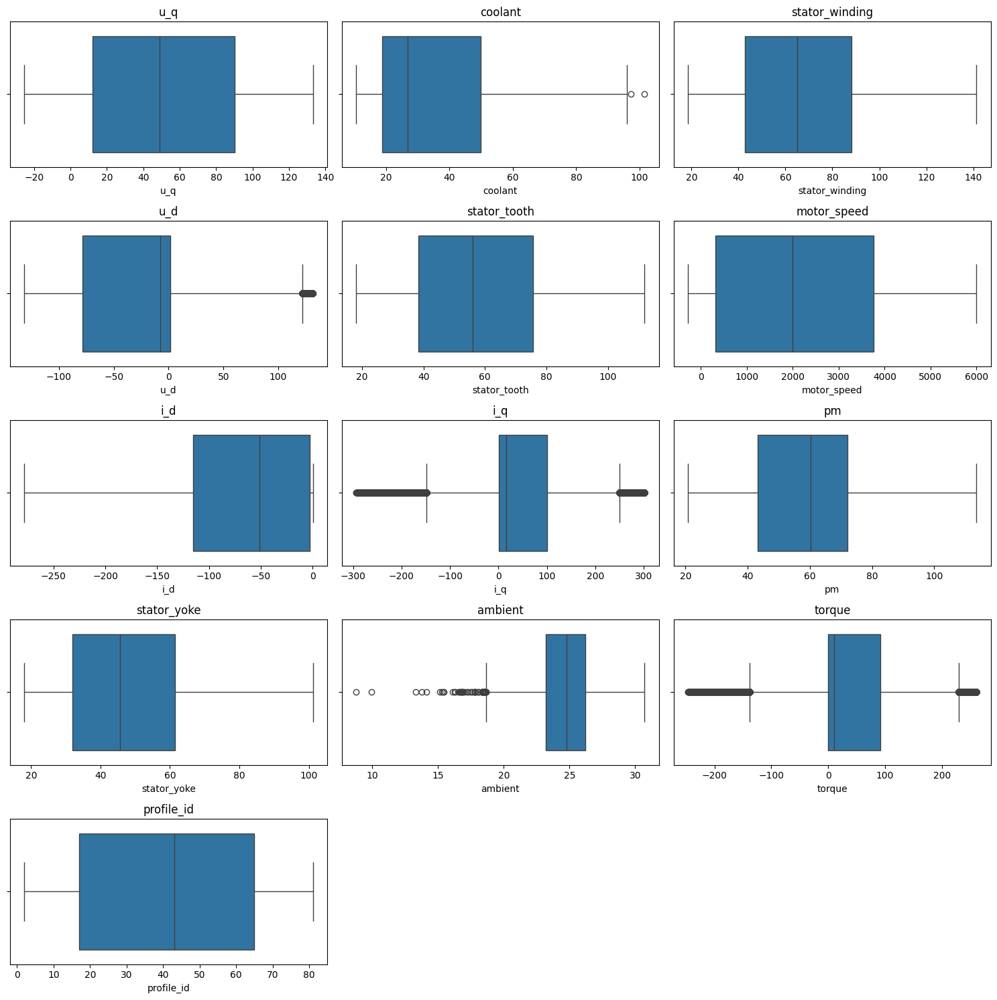

In [9]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) + 2) // 3  
plt.figure(figsize=(15, 3*n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

***Insight:***

>Sebagian besar variabel seperti pm, stator_winding, stator_tooth, stator_yoke, dan motor_speed tidak menunjukkan outlier yang signifikan, sehingga distribusi datanya relatif stabil.

>Beberapa variabel seperti i_q, torque, ambient, dan coolant memiliki beberapa nilai outlier yang berada di luar rentang utama data.

>Variabel ambient memiliki rentang yang relatif sempit dibandingkan variabel lain, menunjukkan bahwa suhu lingkungan cenderung stabil.

***Tindakan:***

>Outlier yang muncul tidak langsung dihapus karena kemungkinan merepresentasikan kondisi operasi motor yang berbeda.

C.3 Menampilkan Pairplot

Karena data memiliki 1.3 Juta baris, kami melakukan sampling untuk mempercepat komputasi

In [10]:
df_sample = df.sample(5000, random_state=42)

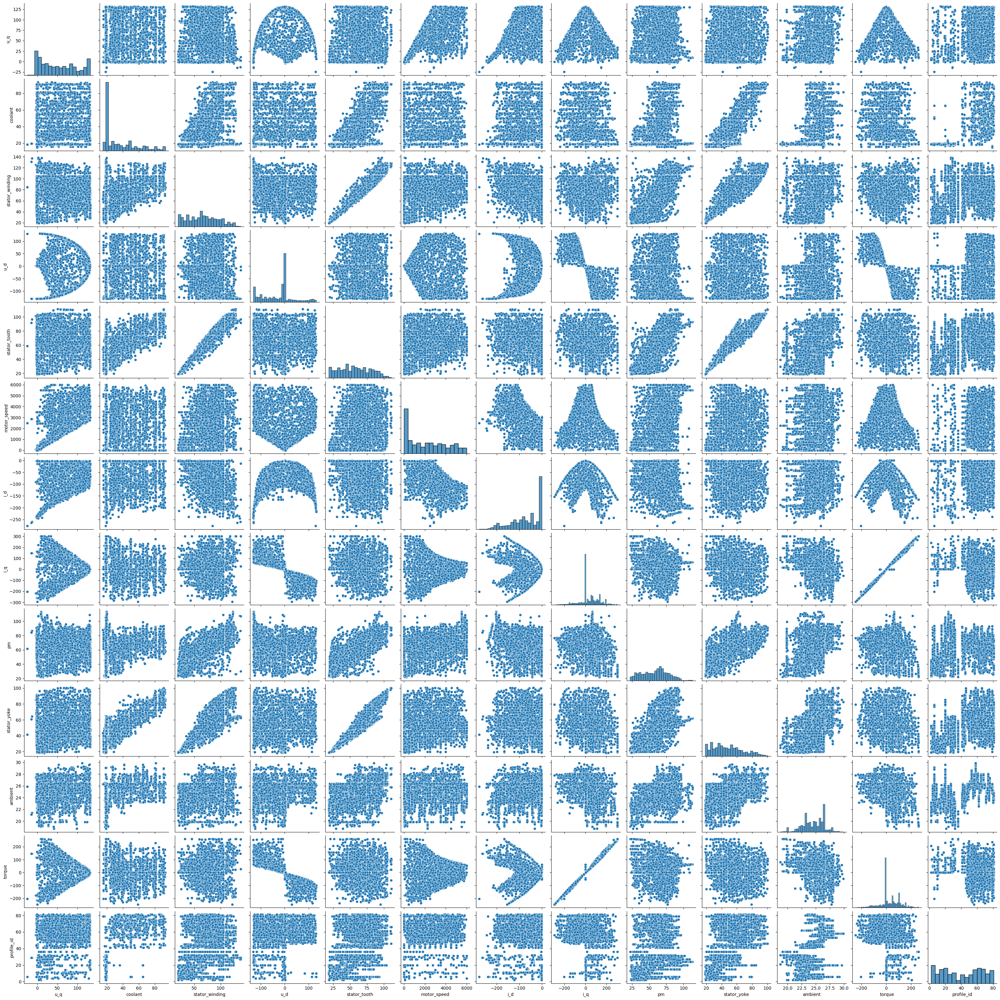

In [11]:
sns.pairplot(df_sample)

***Insight:***

>Variabel temperatur seperti pm, stator_winding, stator_tooth, dan stator_yoke terlihat memiliki hubungan yang cukup kuat satu sama lain, karena titik-titik pada scatter plot membentuk pola yang cenderung searah.

>Variabel motor_speed, torque, dan i_q juga menunjukkan hubungan tertentu dengan pm (temperatur rotor), yang mengindikasikan bahwa kondisi operasi motor dapat mempengaruhi suhu motor.

>Beberapa pasangan variabel tidak menunjukkan pola yang jelas, sehingga kemungkinan hubungannya tidak terlalu kuat.

***Tindakan:***

>Untuk mengetahui hubungan antar variabel secara lebih pasti, selanjutnya dilakukan analisis korelasi menggunakan heatmap.

C.4 Multivariative Analysis

<Axes: >

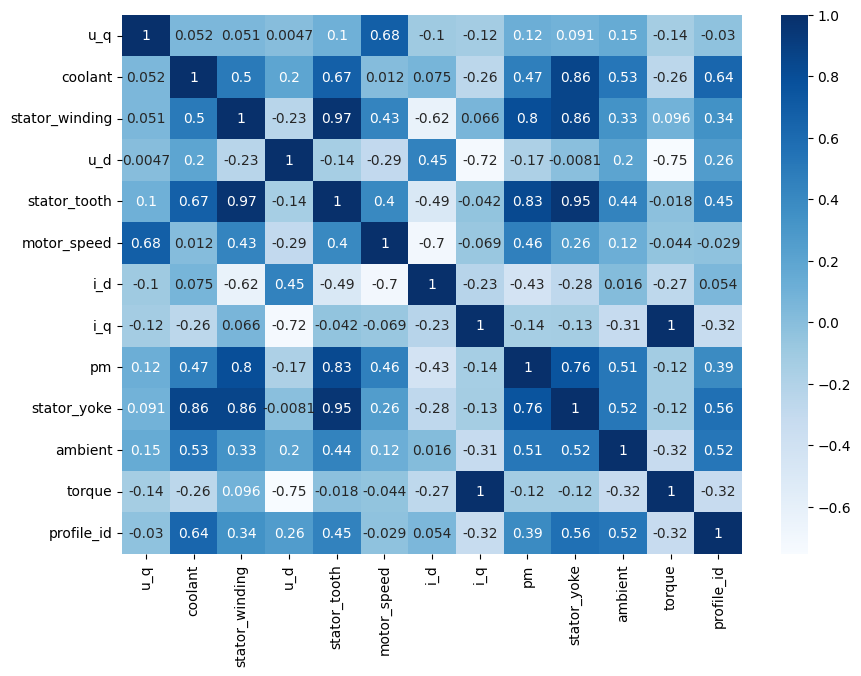

In [12]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='Blues')

***Insight:***

>Variabel temperatur memiliki korelasi yang sangat kuat satu sama lain, seperti stator_winding dengan stator_tooth (0.97) dan stator_tooth dengan stator_yoke (0.95).

>Temperatur rotor pm juga memiliki korelasi cukup kuat dengan stator_tooth (0.83) dan stator_yoke (0.76), yang menunjukkan bahwa kenaikan suhu pada komponen stator berkaitan dengan kenaikan suhu rotor.

>Beberapa variabel operasional seperti motor_speed dan i_d (-0.70) serta u_d dan torque (-0.75) menunjukkan hubungan yang cukup kuat.

----------

# D. Data Preprocessing

D.1 Pemilihan Fitur (Feature Selection)



***Insight:***
>Berdasarkan analisis korelasi sebelumnya, beberapa variabel memiliki hubungan yang sangat kuat satu sama lain, khususnya pada variabel temperatur stator seperti stator_winding, stator_tooth, dan stator_yoke. Selain itu, kolom profile_id hanya berfungsi sebagai identitas eksperimen dan tidak merepresentasikan karakteristik motor.

***Tindakan:***
>Kolom profile_id tidak digunakan dalam proses pemodelan, dan fitur yang digunakan dipilih untuk merepresentasikan kondisi listrik, mekanik, dan temperatur motor.

In [13]:
df = df.drop(columns=['profile_id'])

D.2 Standardisasi Data



***Insight:***
>Beberapa fitur memiliki rentang nilai yang berbeda cukup jauh, misalnya motor_speed yang dapat mencapai ribuan, sedangkan ambient hanya berada di sekitar puluhan. Perbedaan skala ini dapat mempengaruhi hasil clustering.

***Tindakan:***
>Dilakukan standardisasi agar semua fitur memiliki skala yang sebanding sebelum dilakukan proses clustering.

In [14]:
df_model = (df - df.mean()) / df.std()

In [15]:
df_model.std()

u_q              1.00
coolant          1.00
stator_winding   1.00
u_d              1.00
stator_tooth     1.00
motor_speed      1.00
i_d              1.00
i_q              1.00
pm               1.00
stator_yoke      1.00
ambient          1.00
torque           1.00
dtype: float64

In [16]:
df_model.mean()

u_q              -0.00
coolant           0.00
stator_winding   -0.00
u_d               0.00
stator_tooth     -0.00
motor_speed      -0.00
i_d               0.00
i_q               0.00
pm                0.00
stator_yoke      -0.00
ambient          -0.00
torque            0.00
dtype: float64

----------

# E. Pemodelan Bagian 1 : K-Means Clustering

E.1 Membangun class algoritma K-Means

In [ ]:
class KMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    # FUNGSI HELPER -- 

    # Perhitungan jarak
    def euclidean_distance(self, point1, point2):
        return np.sqrt(np.sum((point1 - point2) ** 2))

    # Inisialisasi centroids awal secara acak
    def initialize_centroids(self, X):
        np.random.seed(self.random_state)
        random_indices = np.random.choice(len(X), size=self.k, replace=False)
        return X[random_indices]

    # Menentukan cluster berdasarkan centroid terdekat setiap data
    def assign_clusters(self, X):
        labels = []

        for point in X:
            distances = []
            for centroid in self.centroids:
                distance = self.euclidean_distance(point, centroid)
                distances.append(distance)

            cluster_index = np.argmin(distances)
            labels.append(cluster_index)

        return np.array(labels)

    # Update lokasi centroid berdasarkan rata-rata
    def update_centroids(self, X, labels):
        new_centroids = []

        for i in range(self.k):
            cluster_points = X[labels == i]

            if len(cluster_points) == 0:
                random_point = X[np.random.randint(0, len(X))]
                new_centroids.append(random_point)
            else:
                centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(centroid)

        return np.array(new_centroids)

    # Hitung inertia
    def calculate_inertia(self, X, labels):
        inertia = 0

        for i, point in enumerate(X):
            centroid = self.centroids[labels[i]]
            inertia += self.euclidean_distance(point, centroid) ** 2

        return inertia
    
    # FUNGSI UTAMA --

    # Melatih model 
    def fit(self, X):
        X = np.array(X, dtype=float)
        self.centroids = self.initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self.assign_clusters(X)
            new_centroids = self.update_centroids(X, labels)

            centroid_shift = np.sqrt(np.sum((new_centroids - self.centroids) ** 2))

            self.centroids = new_centroids

            if centroid_shift < self.tol:
                break

        self.labels_ = self.assign_clusters(X)
        self.inertia_ = self.calculate_inertia(X, self.labels_)
        return self

    # Prediksi
    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.assign_clusters(X)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_ 

E.2 Elbow Method untuk mencari k teroptimal

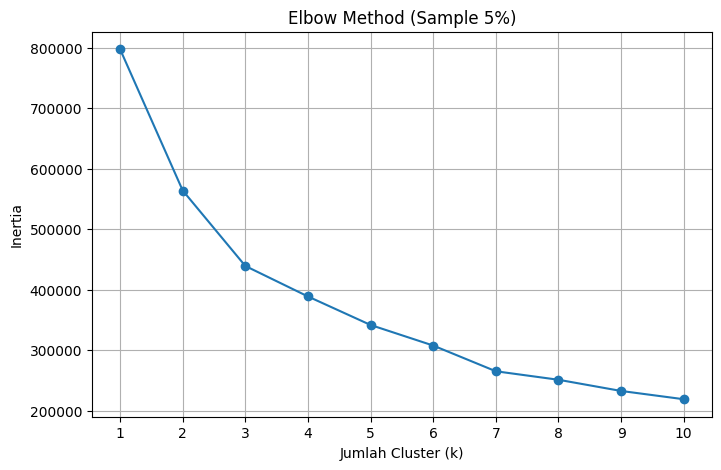

In [18]:
df_sample = df_model.sample(frac=0.05, random_state=42)

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(k=k, max_iters=100, tol=1e-4, random_state=42)
    model.fit(df_sample)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Sample 5%)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

***Insight:***
> Elbow berada pada jumlah cluster (k) 3, yang menunjukan bahwa k 3 merupakan k paling optimal

***Tindakan:***
> Menggunakan k 3 untuk clustering


E.3 Melatih model menggunakan data train 

In [19]:
df_sample_final = df_model.sample(frac=1, random_state=42)
model = KMeans(k=3, max_iters=100, tol=1e-4, random_state=42)
model.fit(df_sample_final)

E.4 Melakukan clustering dengan model yang telah dilatih

In [20]:
clusters = model.predict(df_model)
df['cluster'] = clusters

E.5 Visualisasi hasil clustering pada setiap fitur

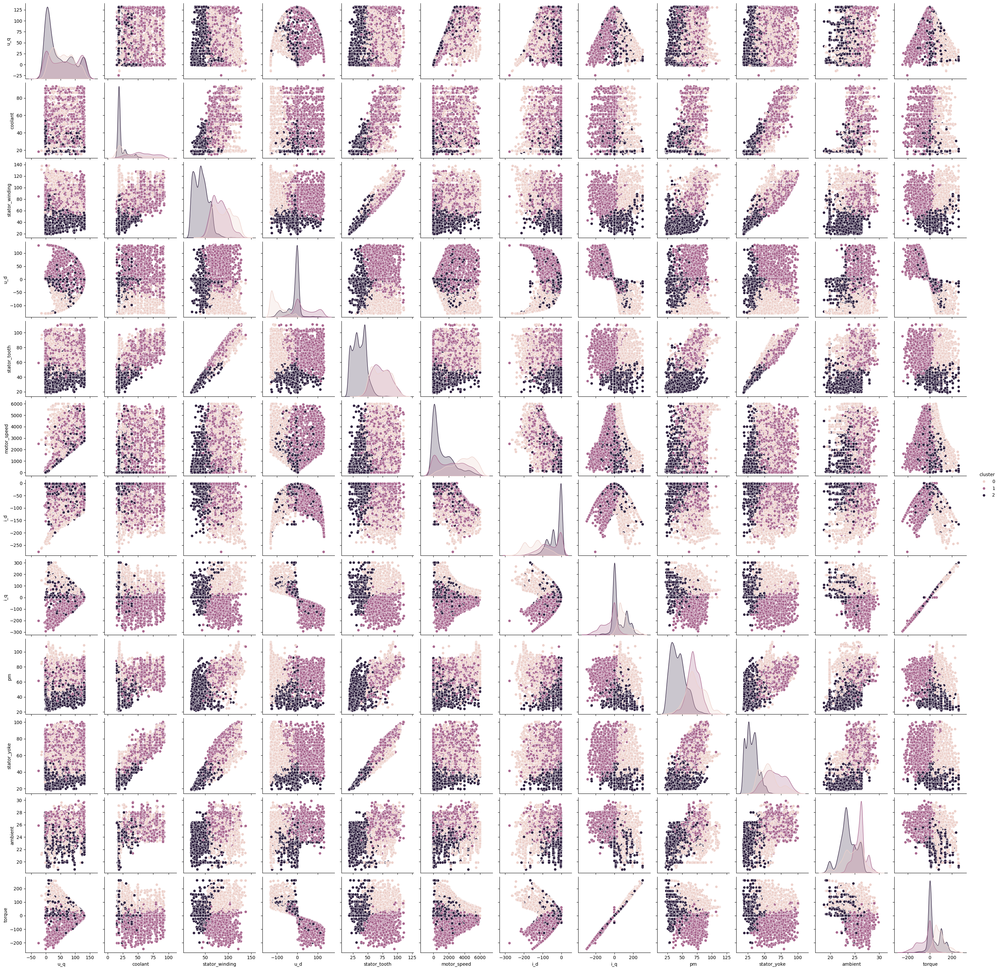

In [21]:
df_sample = df.sample(5000, random_state=42)
sns.pairplot(df_sample, hue='cluster')

***Insight:***
- Untuk mayoritas fitur, cluster dapat terlihat terpisah


E.6 Melakukan PCA untuk visualisasi hasil clustering untuk visualisasi cluster lebih jelas

PCA digunakan hanya untuk visualisasi hasil clustering dengan mereduksi dimensi data menjadi 2 komponen utama. Proses K-Means tetap menggunakan seluruh fitur asli, sehingga PCA tidak mempengaruhi proses pembentukan cluster, melainkan hanya membantu dalam interpretasi visual.

In [22]:
def pca_manual(X, n_components=2):
    
    # Mengubah data menjadi numpy array bertipe float
    # Agar bisa dilakukan operasi matematika
    X = np.array(X, dtype=float)
    
    # Melakukan centering data
    # Setiap nilai dikurangi dengan rata-rata kolomnya
    # Tujuannya agar mean setiap fitur menjadi 0
    X_centered = X - np.mean(X, axis=0)
    
    # Menghitung covariance matrix dari data yang sudah di-center
    # Covariance digunakan untuk melihat hubungan dan variasi antar fitur
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # Melakukan eigen decomposition pada covariance matrix
    # Eigenvalues menunjukkan besar variasi
    # Eigenvectors menunjukkan arah variasi (principal component)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Mengurutkan eigenvalues dari terbesar ke terkecil
    # Karena variasi terbesar dianggap paling penting
    sorted_idx = np.argsort(eigenvalues)[::-1]
    
    # Mengurutkan eigenvalues sesuai indeks yang sudah diurutkan
    eigenvalues = eigenvalues[sorted_idx]
    
    # Mengurutkan eigenvectors mengikuti urutan eigenvalues
    eigenvectors = eigenvectors[:, sorted_idx]
    
    # Memilih beberapa eigenvector pertama sesuai jumlah komponen yang diinginkan
    # Ini akan menjadi principal components
    principal_components = eigenvectors[:, :n_components]
    
    # Melakukan transformasi data ke ruang dimensi baru
    # Dengan memproyeksikan data ke principal components
    X_pca = X_centered @ principal_components
    
    # Menghitung explained variance ratio
    # Untuk mengetahui berapa besar informasi data yang dipertahankan
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    
    # Mengembalikan data yang sudah direduksi dimensinya
    # dan persentase variasi yang dijelaskan oleh komponen yang dipilih
    return X_pca, explained_variance_ratio[:n_components]

In [23]:
df_pca, explained_ratio = pca_manual(df_model, n_components=2)

E.7 Visualisasi cluster

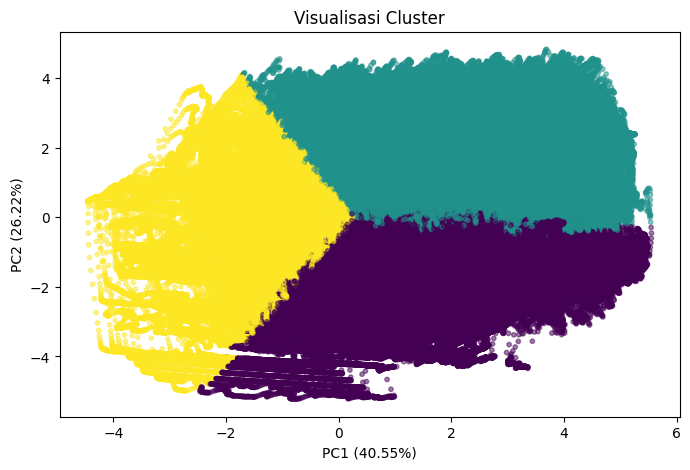

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster'], s=10, alpha=0.5)
plt.xlabel(f'PC1 ({explained_ratio[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({explained_ratio[1]*100:.2f}%)')
plt.title('Visualisasi Cluster')
plt.show()

***Insight:***
- Terlihat tiga kelompok/cluster besar dengan warna berbeda yang relatif terpisah.
Ini menunjukkan bahwa K-Means berhasil menemukan struktur pola yang berbeda pada data fitur-fitur sensor motor.

E.8 Distribusi jumlah data pada setiap cluster

C:\Users\Peser\AppData\Local\Temp\ipykernel_8172\1535585674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['cluster'], palette='Blues')


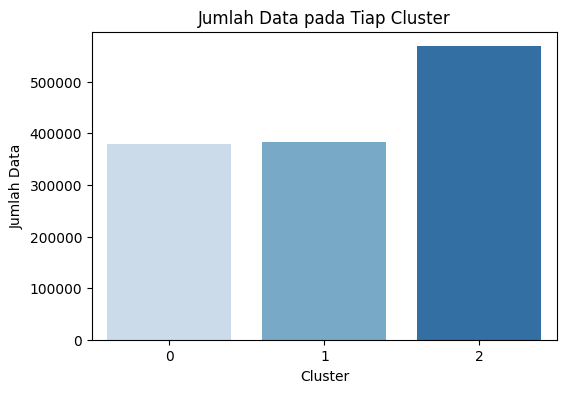

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['cluster'], palette='Blues')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.title('Jumlah Data pada Tiap Cluster')
plt.show()

***Insight:***
- Cluster 2 memiliki jumlah data paling banyak, sedangkan Cluster 0 dan Cluster 1 memiliki jumlah data yang mirip. Hal ini menunjukkan bahwa sebagian besar motor berada pada kondisi Cluster 2. (60:40) bukan imbalanced parah.

***Percobaan:***
- Dataset dapat tetap digunakan tanpa teknik resampling, apakah akan bias?
- Percobaan undersampling data mayoritas, apakah hasil lebih baik?

E.9 Rata-rata nilai fitur pada setiap cluster

In [26]:
cluster_mean = df.groupby('cluster').mean()
cluster_mean

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque
cluster,,,,,,,,,,,,
0,58.24,35.43,90.53,-96.55,72.77,3634.28,-139.29,103.45,71.33,56.83,24.59,90.93
1,60.93,57.00,81.57,34.28,73.33,2218.17,-55.30,-48.62,69.29,65.81,25.97,-41.60
2,47.15,22.77,39.96,-17.51,35.20,1235.96,-30.68,51.30,42.69,30.55,23.60,40.16


E.10 Nilai tengah (median) fitur pada setiap cluster

In [27]:
cluster_median = df.groupby('cluster').median()
cluster_median

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque
cluster,,,,,,,,,,,,
0,57.20,24.88,90.69,-104.76,72.12,3872.23,-137.11,88.22,69.92,54.34,24.84,81.76
1,60.16,55.66,80.26,16.66,71.97,2122.93,-44.01,-21.72,68.92,64.52,26.17,-18.30
2,31.05,18.71,39.39,-3.03,34.90,749.99,-13.56,1.17,41.19,29.61,23.38,0.46


E.11 Analisis arti/interpretasi cluster berdasarkan pola data fitur

1. Cluster 0 = Operasi Berat 
> Penjelasan:
- Motor sedang bekerja dengan beban besar dan kecepatan tinggi
- Torsi paling besar
- Suhu stator_winding tinggi menunjukan motor bekerja keras

2. Cluster 1 = Operasi Sedang 
> Penjelasann:
- torsi negatif + i_q negatif menunjukan berusaha melawan gaya (mungkin untuk memperlambat kecepatan)
- Sistem pendinginan (coolant) lebih aktif

3. Cluster 2 = Operasi ringan 
> Penjelasan:
- Motor tidak menghasilkan banyak torsi
- Arus kecil
- Kecepatan rendah


***Catatan:***
> Interpretasi kondisi pada setiap cluster merupakan hasil analisis pola data. Karena metode ini bersifat unsupervised, penamaan cluster hanya berdasarkan ciri nilai fitur dan bukan merupakan ground truth, sehingga masih butuh validasi profesional lebih lanjut.

E.12 Final dataset

In [28]:
df.head(10)

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,cluster
0,-0.45,18.81,19.09,-0.35,18.29,0.00,0.00,0.00,24.55,18.32,19.85,0.19,2
1,-0.33,18.82,19.09,-0.31,18.29,0.00,0.00,-0.00,24.54,18.31,19.85,0.25,2
2,-0.44,18.83,19.09,-0.37,18.29,0.00,0.00,0.00,24.54,18.33,19.85,0.18,2
3,-0.33,18.84,19.08,-0.32,18.29,0.01,0.00,0.00,24.55,18.33,19.85,0.24,2
4,-0.47,18.86,19.08,-0.33,18.29,0.00,-0.06,0.04,24.57,18.33,19.85,0.21,2
5,-0.54,18.90,19.08,0.01,18.29,0.01,-0.61,0.34,24.57,18.32,19.85,0.48,2
6,-0.65,18.94,19.07,0.24,18.29,0.00,-1.01,0.55,24.58,18.32,19.85,0.67,2
7,-0.76,18.96,19.08,0.40,18.29,0.00,-1.29,0.71,24.57,18.31,19.85,0.75,2
8,-0.73,18.97,19.09,0.55,18.29,0.00,-1.49,0.82,24.57,18.31,19.85,0.91,2
9,-0.87,18.99,19.08,0.58,18.29,-0.00,-1.63,0.90,24.55,18.30,19.85,0.92,2


E.13 Pemisahan data latih (train) dan data uji (test) menggunakan metode stratified

In [29]:
def stratified_split(df, kolom_label):
    daftar_train = []
    daftar_test = []
    labels = df[kolom_label].unique()
    for label in labels:
        label_train = df[df[kolom_label] == label].sample(frac=0.7, random_state=42, replace=False)
        label_test = df[df[kolom_label] == label].drop(label_train.index)
        daftar_train.append(label_train)
        daftar_test.append(label_test)

    daftar_train = pd.concat(daftar_train)
    daftar_test = pd.concat(daftar_test)

    x_te = daftar_test.iloc[:,:-1]
    y_te = daftar_test[kolom_label]

    return daftar_train, x_te.values, y_te.values

In [30]:
df_train, x_te, y_te = stratified_split(df, 'cluster')

**Alasan 70:30:**
- Data uji sebesar 70% dari 1 juta data merupakan sudah sangat banyak dan cukup untuk melatih model
- Data test 30% memberikan ukuran sampel yang besar, estimasi metrik seperti akurasi, precision, dan recall akan menjadi lebih stabil dan tidak mudah dipengaruhi variasi data daripada hanya 20% atau 15% saja.

E.14 Distribusi label pada data latih/train

C:\Users\Peser\AppData\Local\Temp\ipykernel_8172\2484823144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_train['cluster'], palette='Blues')


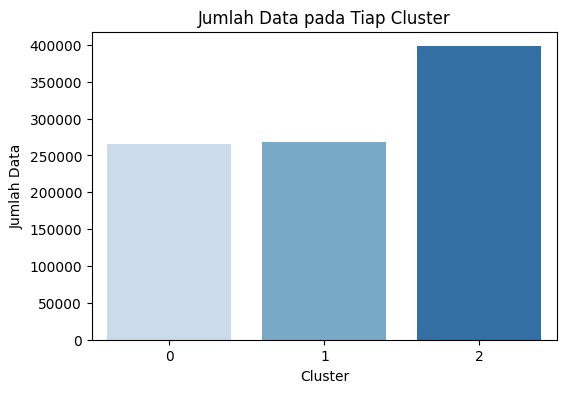

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_train['cluster'], palette='Blues')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.title('Jumlah Data pada Tiap Cluster')
plt.show()

E.15 Fungsi undersampling untuk percobaan

In [32]:
def undersampling(df, kolom_label, threshold):
    for l in df[kolom_label].unique():
        major_data = df[df[kolom_label] == l]
        if len(major_data) > threshold:
            df_l = major_data.sample(threshold, random_state=42)
            df = pd.concat([df, df_l], axis=0)

    df = df.reset_index(drop=True)
    return df

E.16 Penerapan percobaan undersampling

In [33]:
# df_train = undersampling(df_train, 'cluster', 270000)

E.16 Visualisasi hasil undersampling

In [34]:
# plt.figure(figsize=(6, 4))
# sns.countplot(x=df_train['cluster'], palette='Blues')
# plt.xlabel('Cluster')
# plt.ylabel('Jumlah Data')
# plt.title('Jumlah Data pada Tiap Cluster')
# plt.show()

E.16 Pemisahan fitur dan target train

In [35]:
x_tr = df_train.iloc[:,:-1].values
y_tr = df_train['cluster'].values

In [36]:
print(x_tr.shape)
print(y_tr.shape)
print(x_te.shape)
print(y_te.shape)

(931572, 12)
(931572,)
(399244, 12)
(399244,)


--------

# F. Pemodelan Bagian 2 : Decision Tree CART & Random Forest

**Keunggukan Decision Tree CART:**
- Komputasi lebih cepat daripada jenis Decision Tree lain (ID3 & C4.5) karena menggunakan rumus Gini, bukan Entropy.
- Gini lebih mudah diinterpretasikan.
- Cocok untuk data kontinu dan kategorikal.

**Hipotesis:**
- Metode Ensemble (Random forest) akan memiliki performa prediksi kondisi motor yang lebih bagus daripada Decision Tree murni 

F.1 Membangun class algoritma Decision Tree

In [37]:
class DecisionTree:
    def __init__(self, max_depth=5, n_splits=20, max_features=None):
        self.max_depth = max_depth
        self.n_splits = n_splits
        self.max_features = max_features
        self.tree = None

    # FUNGSI HELPER --

    # Label paling sering muncul pada suatu node
    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]

    # Seberapa campur label pada suatu node
    def gini_impurity(self, y):
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs**2)
    
    # Besaran pengurangan gini impurity setelah percobaan split
    def gini_gain(self, parent, left, right):
        gini_parent = self.gini_impurity(parent)

        gini_left = self.gini_impurity(left)
        gini_right = self.gini_impurity(right)

        left_w = len(left) / len(parent)
        right_w = len(right) / len(parent)

        return gini_parent - (left_w * gini_left + right_w * gini_right)
    
    # FUNGSI UTAMA --

    # Bangun pohon secara rekrusif
    def build_tree(self, x, y, depth):
        
        # Jika kedalaman maksimal atau tersisa satu jenis label, kembalikan label sering muncul (menjadi leaf)
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return self.most_common_value(y)
        
        # Apakah ada batasan jumlah fitur digunakan
        n_features = x.shape[1]

        if self.max_features is None:
            features = range(n_features)
        else:
            features = np.random.choice(n_features, self.max_features, replace=False)

        # Cari kombinasi fitur dan threshold terbaik 
        best_feature = None
        best_split = None
        best_gain = -np.inf

        # Coba untuk setiap fitur
        for feature in features:

            # Membagi nilai pada fitur menjadi n bagian thresholds
            values = x[:, feature]
            thresholds = np.linspace(values.min(), values.max(), self.n_splits)
            
            # Coba untuk setiap nilai threshold
            for value in thresholds:

                left_mask = values <= value
                right_mask = values > value

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                # gini gain hasils split saat ini
                gain = self.gini_gain(y, y[left_mask], y[right_mask])

                # jika lebih bagus, simpan fitur dan threshold
                if gain > best_gain:
                    best_feature = feature
                    best_split = value
                    best_gain = gain

        # Jika tidak ditemukan fitur terbaik, kembalikan label sering muncul (menjadi leaf)
        if best_feature is None:
            return self.most_common_value(y)

        # Splitting sesuai threshold terbaik
        left_mask = x[:, best_feature] <= best_split
        right_mask = x[:, best_feature] > best_split

        return {
            'feature': best_feature,
            'split': best_split,
            'left': self.build_tree(x[left_mask], y[left_mask], depth + 1), 
            'right': self.build_tree(x[right_mask], y[right_mask], depth + 1)
        }
    
    # Latih model
    def fit(self, x, y):
        self.tree = self.build_tree(x, y, 0)

    # Prediksi label suatu sampel
    def predict_sample(self, tree, sample):

        if not isinstance(tree, dict):
            return tree

        feature_index = tree['feature']
        split_value = tree['split']

        if sample[feature_index] <= split_value:
            return self.predict_sample(tree['left'], sample) 
        else:
            return self.predict_sample(tree['right'], sample)

    # Prediksi label-label kumpulan sampel
    def predict(self, x):
        return np.array([self.predict_sample(self.tree, s) for s in x])

F.2 Membangun class algoritma Random Forest 

In [ ]:
class RandomForest:
    def __init__(self, n_trees=50, max_depth=5, n_splits=20, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.n_splits = n_splits
        self.max_features = max_features
        self.trees = []
    
    # FUNGSI HELPER --
    
    # Sampling data secara random agar struktur setiap pohon bervariasi
    def bootstrap_sample(self, x, y):

        n_samples = x.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)

        return x[indices], y[indices]
    
    # FUNGSI UTAMA --

    # Melatih model (Membangun kumpulan pohon)
    def fit(self, x, y):

        self.trees = []

        for _ in range(self.n_trees):

            x_sample, y_sample = self.bootstrap_sample(x, y)

            tree = DecisionTree(
                max_depth=self.max_depth,
                n_splits=self.n_splits,
                max_features=self.max_features
            )

            tree.fit(x_sample, y_sample)

            self.trees.append(tree)

    # Prediksi label data baru berdasarkan voting label yang dihasilkan setiap pohon
    def predict(self, x):

        tree_preds = np.array([tree.predict(x) for tree in self.trees])

        tree_preds = np.swapaxes(tree_preds, 0, 1)

        predictions = []

        for preds in tree_preds:

            unique, counts = np.unique(preds, return_counts=True)
            predictions.append(unique[np.argmax(counts)])

        return np.array(predictions)

F.3 Melakukan grid search untuk menentukan kedalaman optimal pohon

In [39]:
def grid_search(depths, x_tr, y_tr, x_te, y_te):
    akurasi_tr = []
    akurasi_te = [] 

    # Hitung akurasi train test di setiap depth
    for d in depths:
        model = DecisionTree(d)
        model.fit(x_tr, y_tr)
        y_tr_pred = model.predict(x_tr)
        y_te_pred = model.predict(x_te)

        akurasi_tr.append(np.mean(y_tr == y_tr_pred))
        akurasi_te.append(np.mean(y_te == y_te_pred))

        print(f'Depth {d} ✅')

    akurasi_df = pd.DataFrame(data={'Train': akurasi_tr, 'Test' : akurasi_te}, index=depths)
    return akurasi_df

In [40]:
akurasi_df = grid_search([x for x in range(1,16)], x_tr, y_tr, x_te, y_te)

Depth 1 ✅
Depth 2 ✅
Depth 3 ✅
Depth 4 ✅
Depth 5 ✅
Depth 6 ✅
Depth 7 ✅
Depth 8 ✅
Depth 9 ✅
Depth 10 ✅
Depth 11 ✅
Depth 12 ✅
Depth 13 ✅
Depth 14 ✅
Depth 15 ✅


F.4 Visualisasi akurasi train dan test berdasarkan berbagai depth

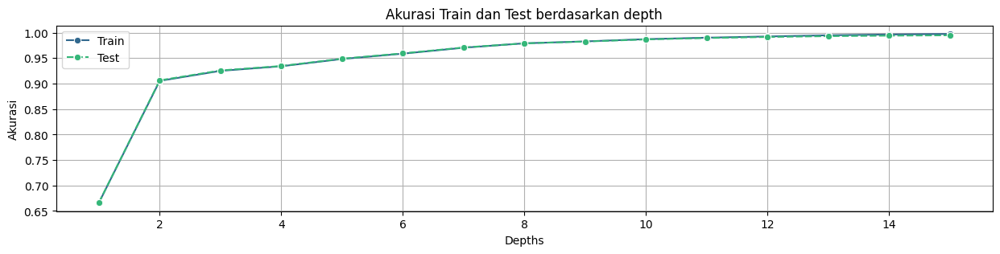

In [41]:
plt.figure(figsize=(15,3))
sns.lineplot(data=akurasi_df, marker='o', palette='viridis')
plt.legend()
plt.grid()
plt.title('Akurasi Train dan Test berdasarkan depth')
plt.xlabel('Depths')
plt.ylabel('Akurasi')
plt.show()

***Insight:***
- Akurasi train dan test cenderung tidak jauh berbeda sepanjang kedalaman
- Peningkatan akurasi mulai sangat tidak signifikan pada kedalaman >=12

F.5 Visualisasi selisih/error akurasi train terhadap test

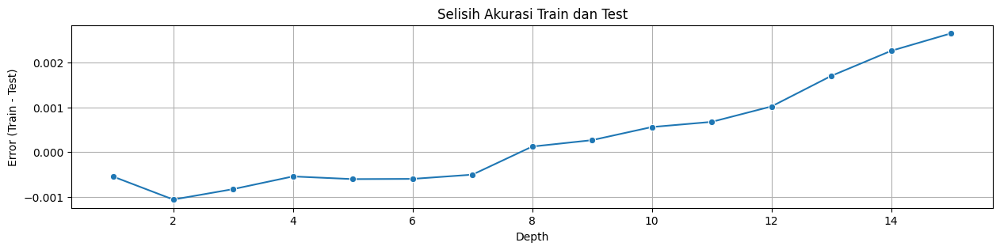

In [42]:
akurasi_df['error'] = akurasi_df['Train'] - akurasi_df['Test']

plt.figure(figsize=(15,3))
sns.lineplot(x=akurasi_df.index, y=akurasi_df['error'], marker='o')
plt.grid()
plt.title('Selisih Akurasi Train dan Test')
plt.xlabel('Depth')
plt.ylabel('Error (Train - Test)')
plt.show()

***Insight:***
- Semakin dalam pohon maka semakin tinggi akurasi train dan test
- Jika kedalaman telah melebihi 5, selisih/error akan terus meningkat

***Tindakan:***
- Menggunakan kedalaman 12 untuk melatih model

***Alasan:***
- Tidak melebihi jumlah fitur
- Menghasilkan akurasi, presisi dan recall yang sudah tinggi
- Jika lebih dari 12 sudah tidak ada perubahan akurasi, presisi dan recall yang signifikan

F.6 Melatih model decision tree menggunakan kedalaman optimal

In [43]:
dc = DecisionTree(max_depth=12)
dc.fit(x_tr, y_tr)

F.7 Visualisasi hasil pohon 

In [44]:
def plot_tree(node,feature_names, x=0.5, y=1, dx=0.25, dy=0.08, ax=None, depth=0, max_depth=4):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20,10))
        ax.axis("off")

    if not isinstance(node, dict):
        ax.text(
            x, y,
            f"Label: {node}",
            ha="center",
            bbox=dict(boxstyle="round", fc="#b3ade6")
        )
        return ax

    if depth >= max_depth:
        ax.text(
            x, y,
            "...",
            ha="center",
            bbox=dict(boxstyle="round", fc="#f46161")
        )
        return ax

    feature = feature_names[node["feature"]]
    split = node["split"]

    label = f"{feature} ≤ {split:.2f}"

    ax.text(
        x, y,
        label,
        ha="center",
        bbox=dict(boxstyle="round", fc="#90E0EE")
    )

    ax.plot([x, x-dx], [y, y-dy], 'k-')
    plot_tree(node["left"], feature_names, x-dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    ax.plot([x,x+dx], [y, y-dy], 'k-')
    plot_tree(node["right"], feature_names, x+dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    return ax

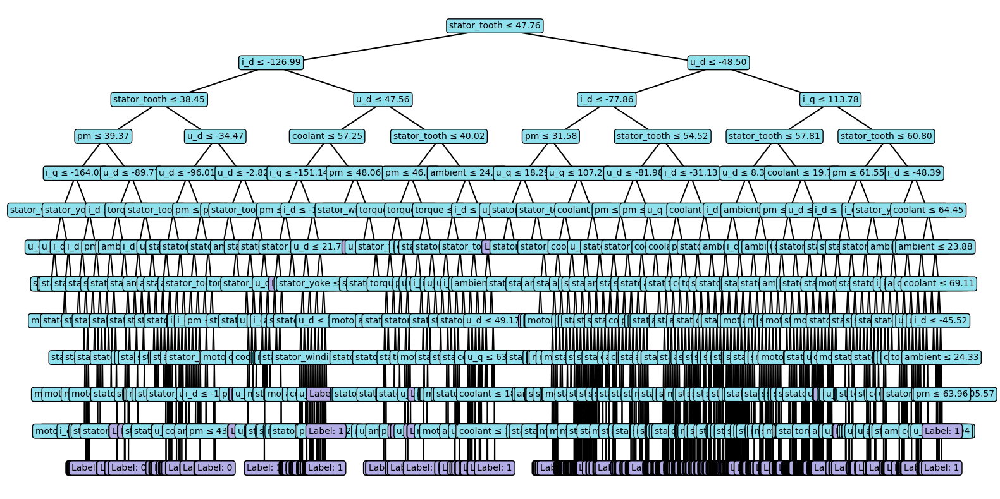

In [ ]:
colom = df.iloc[:,:-1].columns
plot_tree(dc.tree, colom, max_depth=12)
plt.show() 

***Insight:***
- Fitur stator tooth merupakan fitur paling berpengaruh karena menjadi root
- Diikuti fitur i_d dan u_d berada pada level selanjutnya menunjukan arus dan tegangan motor juga sangat mempengaruhi klasifikasi kondisi operasi

F.8 Melatih model Random Forest 

Parameter Digunakan:
- jumlah pohon (n_trees) = 100
- kedalaman maksimal pohon (max_depth) = 20
- jumlah maksimal fitur yang dipakai per pohon (max_features) = 3

Prameter Percobaan:
- n_trees = 100
- max_depth = 6
- max_features = 3
- Akurasi = 99.02%

In [46]:
rf = RandomForest(
    n_trees=100,
    max_depth=20,
    max_features=3
)
rf.fit(x_tr, y_tr)

KeyboardInterrupt: 

F.9 Prediksi label dari data train dan test menggunakan Decision Tree dan Random Forest untuk mengukur performa masing-masing 
model

In [ ]:
y_te_pred = dc.predict(x_te)
y_tr_pred = dc.predict(x_tr)

In [ ]:
y_te_pred_rf = rf.predict(x_te)
y_tr_pred_rf = rf.predict(x_tr)

-------

# G. Evaluasi

G.1 Fungsi confussion matrix dan metrik evaluasi

In [ ]:
labels = ['Operasi Berat','Operasi Sedang', 'Operasi Ringan']
def evaluasi_model(y,y_pred):
    lbl = np.unique(np.concatenate((y,y_pred)))
    cm = pd.DataFrame(np.zeros([len(lbl), len(lbl)]), columns=lbl, index=lbl, dtype=int)

    for a,p in zip(y,y_pred):
        cm.loc[a,p] += 1

    print(f'Akurasi : {np.mean(y == y_pred)*100:.2f}%')

    for l in lbl:
        tp = cm.loc[l,l]
        fp = cm[l].sum() - tp
        fn = cm.loc[l].sum() - tp

        presisi = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1_score = (presisi+recall) /2

        print(f'------- Cluster {labels[l]}')
        print(f'Presisi  : {presisi:.5f}')
        print(f'Recall   : {recall:.5f}')
        print(f'F1 Score : {f1_score:.5f}')

    sns.heatmap(data=cm, fmt='d', annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predict')
    plt.ylabel('Actual')
    plt.show()

G.2 Evaluasi performa model Decision Tree terhadap data baru

Akurasi : 99.16%
------- Cluster Operasi Berat
Presisi  : 0.99089
Recall   : 0.99278
F1 Score : 0.99183
------- Cluster Operasi Sedang
Presisi  : 0.98908
Recall   : 0.98853
F1 Score : 0.98880
------- Cluster Operasi Ringan
Presisi  : 0.99383
Recall   : 0.99294
F1 Score : 0.99339


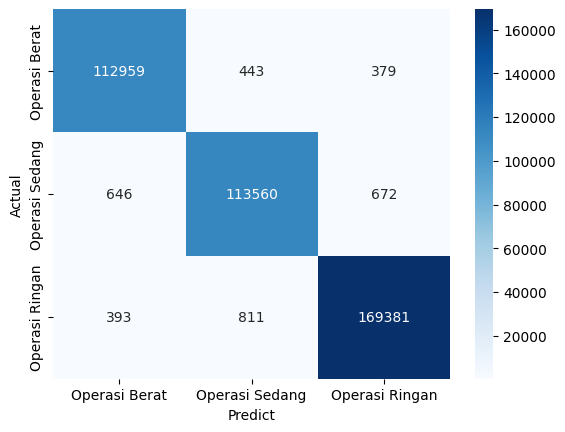

In [ ]:
evaluasi_model(y_te, y_te_pred)

G.3 Evaluasi performa model Random Forest terhadap data baru

Akurasi : 99.79%
------- Cluster Operasi Berat
Presisi  : 0.99713
Recall   : 0.99737
F1 Score : 0.99725
------- Cluster Operasi Sedang
Presisi  : 0.99713
Recall   : 0.99775
F1 Score : 0.99744
------- Cluster Operasi Ringan
Presisi  : 0.99896
Recall   : 0.99838
F1 Score : 0.99867


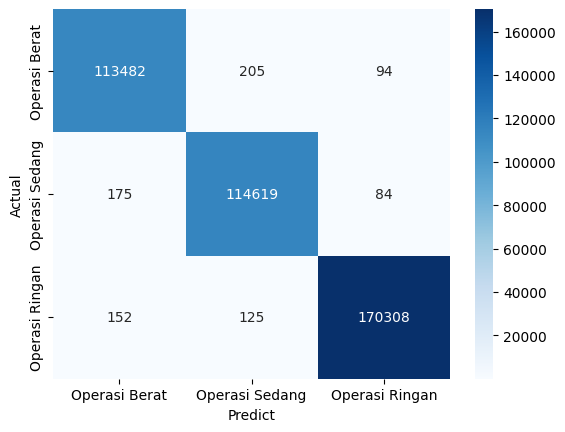

In [ ]:
evaluasi_model(y_te, y_te_pred_rf)

### **KESIMPULAN**

- Proses pengelompokan menggunakan K-Means Clustering berhasil membagi data sensor motor listrik ke dalam 3 cluster yang merepresentasikan pola kondisi operasional yang berbeda (Ringan, Sedang dan Berat). Ini menunjukkan bahwa data sensor cukup informatif untuk membedakan kondisi operasi motor listrik.

- Hasil eksperimen menunjukkan bahwa penerapan undersampling tidak memberikan peningkatan performa yang signifikan dibandingkan dataset asli. Hal ini menunjukan distribusi label yang relatif seimbang (60:40).

- Hasil evaluasi menunjukkan bahwa Random Forest memberikan performa yang lebih baik dibandingkan Decision Tree dalam memprediksi kondisi operasional motor, ditunjukkan oleh akurasi dan kestabilan presisi dan recall yang lebih tinggi.

- Secara keseluruhan, pendekatan kombinasi clustering dan klasifikasi (khususnya algoritma random forest) ini mampu membantu dalam mengidentifikasi serta memprediksi kondisi motor listrik berdasarkan pola data sensor secara lebih efektif.

--------

# H. Graphical User Interface (GUI)

In [47]:
from tkinter import *
from tkinter import messagebox

# H.1 Warna dan Fitur
BG_MAIN = "#0d1117"
BG_PANEL = "#161b22"
BG_INPUT = "#21262d"

TEXT_MAIN = "#e6edf3"
TEXT_ACCENT = "#58a6ff"

BTN_BG = "#238636"
BTN_ACTIVE = "#2ea043"

fitur = [
    "u_q","coolant","stator_winding","u_d","stator_tooth",
    "motor_speed","i_d","i_q","pm","stator_yoke","ambient","torque"
]

entries = {}


# H.2 Fungsi submit prediksi label data input
def submit():
    try:
        data = []

        for f in fitur:
            value = float(entries[f].get())
            data.append(value)

        y_pred_baru = dc.predict([data])

        match y_pred_baru[0]:
            case 0:
                hasil = "Operasi Berat"
            case 1:
                hasil = "Operasi Menengah"
            case 2:
                hasil = "Operasi Ringan"

        messagebox.showinfo("Hasil Prediksi", hasil)

    except:
        messagebox.showerror("Error", "Pastikan semua input berupa angka")

# H.3 UI/UX
window = Tk()
window.geometry("450x700")
window.configure(bg=BG_MAIN)
window.title("Kondisi Operasional Monitoring")

frame_1 = Frame(window, bg=BG_PANEL)
frame_1.pack(fill="x")

logo_left = Label(
    frame_1,
    text="Kondisi Operasional Monitoring",
    bg=BG_PANEL,
    fg=TEXT_ACCENT,
    font=("Segoe UI", 15, "bold")
)
logo_left.pack(padx=10, pady=10)

label_title = Label(
    window,
    text="Prediksi Kondisi Motor Listrik",
    font=("Segoe UI", 16, "bold"),
    bg=BG_MAIN,
    fg=TEXT_MAIN
)
label_title.pack(pady=15)

form_frame = Frame(window, bg=BG_MAIN)
form_frame.pack()

for i, f in enumerate(fitur):
    label = Label(
        form_frame,
        text=f,
        bg=BG_MAIN,
        fg=TEXT_ACCENT,
        font=("Segoe UI", 11)
    )
    label.grid(row=i, column=0, padx=10, pady=5, sticky="w")

    entry = Entry(
        form_frame,
        font=("Segoe UI", 11),
        width=20,
        bg=BG_INPUT,
        fg=TEXT_MAIN,
        insertbackground=TEXT_MAIN,
        relief=FLAT
    )
    entry.grid(row=i, column=1, padx=10, pady=5)

    entries[f] = entry


button_aes = Button(
    window,
    text="Predict",
    font=("Segoe UI", 13, "bold"),
    bg=BTN_BG,
    fg="white",
    activebackground=BTN_ACTIVE,
    relief=FLAT,
    padx=15,
    pady=6,
    command=submit
)
button_aes.pack(pady=20)

frame_2 = Frame(window, bg=BG_PANEL)
frame_2.pack(fill=BOTH, side=BOTTOM)

logo_down = Label(
    frame_2,
    text="Model AI ini memiliki akurasi 99.79%",
    bg=BG_PANEL,
    fg=TEXT_ACCENT,
    font=("Segoe UI", 11, "bold")
)
logo_down.pack(pady=6)

window.mainloop()

## Daftar Isi

1. [Business Understanding](#a-business-understanding)
2. [Data Understanding](#b-data-understanding)
3. [Exploratory Data Analysis](#c-exploratory-data-analysis)
4. [Data Preprocesing](#d-data-preprocessing)
5. [Pemodelan Bagian 1 : K-Means Clustering](#e-pemodelan-bagian-1--k-means-clustering)
6. [Pemodelan Bagian 2 : Decision Tree](#f-pemodelan-bagian-2--decision-tree)
7. [Evaluasi](#g-evaluasi)
8. [Graphical User Interface](#h-graphical-user-interface-gui)